In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from ctgan import CTGAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Loading Real D&D Data...")
df = pd.read_csv('clean_aggregated_combat_data.csv')

# --- Feature Engineering (Same as before) ---
class_columns = ['num_barbarian', 'num_bard', 'num_cleric', 'num_druid', 'num_fighter', 
                 'num_monk', 'num_paladin', 'num_ranger', 'num_rogue', 'num_sorcerer', 
                 'num_warlock', 'num_wizard']

df['party_size'] = df[class_columns].sum(axis=1).replace(0, 1)
df['avg_party_level'] = df['avg_party_level'].replace(0, 1)
df['true_party_power'] = df['party_size'] * (df['avg_party_level'] ** 1.5)
df['cr_to_party_power'] = df['avg_monster_cr'] / df['true_party_power']
df['monster_hp_per_player'] = df['avg_monster_hp'] / df['party_size']

df['has_healer'] = ((df['num_cleric'] > 0) | (df['num_druid'] > 0) | (df['num_bard'] > 0)).astype(int)
df['has_tank'] = ((df['num_barbarian'] > 0) | (df['num_fighter'] > 0) | (df['num_paladin'] > 0)).astype(int)
df['has_arcane'] = ((df['num_wizard'] > 0) | (df['num_sorcerer'] > 0) | (df['num_warlock'] > 0)).astype(int)
df['has_martial_dps'] = ((df['num_rogue'] > 0) | (df['num_monk'] > 0) | (df['num_ranger'] > 0)).astype(int)

df['target'] = df['final_outcome'].apply(lambda x: 1 if x == 'Party Win' else 0)

features = ['avg_party_level', 'party_size', 'cr_to_party_power', 'monster_hp_per_player', 
            'avg_monster_ac', 'has_healer', 'has_tank', 'has_arcane', 'has_martial_dps']

# Drop NAs
df_model = df[features + ['target']].dropna()

# =========================================================
# THE CRITICAL FIX: Split the data BEFORE generating fakes!
# =========================================================
print("\n2. Splitting into Train and Test Sets...")
X = df_model[features]
y = df_model['target']

# 80% for training, 20% for the locked Test Vault
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================
# 3. Apply the GAN *ONLY* to the Training Data
# =========================================================
print("\n3. Training GAN only on the Training Losses...")
# Combine X_train and y_train temporarily so the GAN can learn the relationships
train_data = X_train.copy()
train_data['target'] = y_train

# Isolate the losses in the training set
train_losses = train_data[train_data['target'] == 0]

# Train the GAN
discrete_columns = ['party_size', 'has_healer', 'has_tank', 'has_arcane', 'has_martial_dps', 'target']
ctgan = CTGAN(epochs=150, verbose=False) # Reduced epochs for speed, you can bump to 300
ctgan.fit(train_losses, discrete_columns)

# Generate synthetic losses to match the number of wins in the training set
num_wins_in_train = len(train_data[train_data['target'] == 1])
num_losses_in_train = len(train_losses)
needed_synthetic_losses = num_wins_in_train - num_losses_in_train

print(f"Generating {needed_synthetic_losses} synthetic training losses...")
synthetic_losses = ctgan.sample(needed_synthetic_losses)

# Combine the real training data with the synthetic training data
balanced_train_data = pd.concat([train_data, synthetic_losses], ignore_index=True)

X_train_bal = balanced_train_data[features]
y_train_bal = balanced_train_data['target']


1. Loading Real D&D Data...

2. Splitting into Train and Test Sets...

3. Training GAN only on the Training Losses...
Generating 18457 synthetic training losses...



=== 4. THE ALGORITHM SHOWDOWN ===
Training Logistic Regression (Baseline)...
-> Logistic Regression Accuracy: 59.88%
Training XGBoost (Raw Power)...
-> XGBoost Accuracy: 88.30%
Fine-Tuning Random Forest via RandomizedSearchCV...
-> Tuned Random Forest Accuracy: 95.45%
-> Best RF Parameters Found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

=== 5. FINAL CLASSIFICATION REPORT (BEST MODEL) ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1174
           1       0.98      0.97      0.97      5808

    accuracy                           0.95      6982
   macro avg       0.91      0.93      0.92      6982
weighted avg       0.96      0.95      0.95      6982

Saved final feature importance chart to 'ultimate_feature_importance.png'


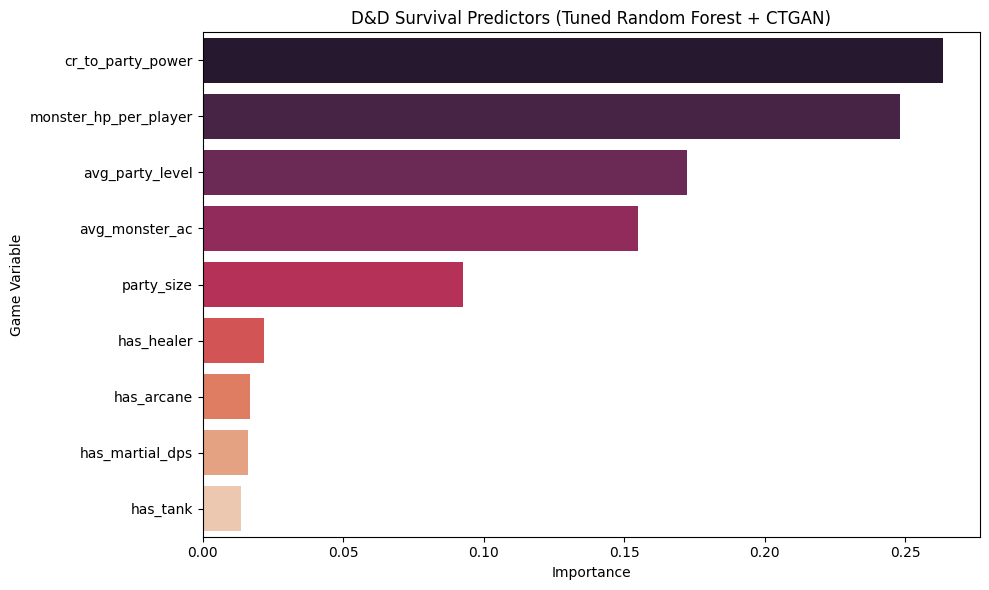

In [5]:
X_train_bal = balanced_train_data[features]
y_train_bal = balanced_train_data['target']
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from ctgan import CTGAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
print("\n=== 4. THE ALGORITHM SHOWDOWN ===")

# --- A. Baseline: Logistic Regression ---
print("Training Logistic Regression (Baseline)...")
# LR needs scaled data to work properly with continuous math like HP and CR
lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
lr_pipe.fit(X_train_bal, y_train_bal)
lr_pred = lr_pipe.predict(X_test)
print(f"-> Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")

# --- B. Heavyweight: XGBoost ---
print("Training XGBoost (Raw Power)...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal)
xgb_pred = xgb.predict(X_test)
print(f"-> XGBoost Accuracy: {accuracy_score(y_test, xgb_pred) * 100:.2f}%")

# --- C. The Storyteller: Fine-Tuned Random Forest ---
print("Fine-Tuning Random Forest via RandomizedSearchCV...")
# Define the "hyperparameter grid" to search through
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instead of checking every combination (which takes hours), RandomizedSearchCV checks 10 smart combinations
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=rf_param_grid, 
                               n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
rf_search.fit(X_train_bal, y_train_bal)
best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(X_test)
print(f"-> Tuned Random Forest Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print(f"-> Best RF Parameters Found: {rf_search.best_params_}")

print("\n=== 5. FINAL CLASSIFICATION REPORT (BEST MODEL) ===")
# We assume the Tuned RF or XGBoost won. Let's print the report for the Tuned RF.
print(classification_report(y_test, rf_pred))

# Plot Feature Importance of the Best Random Forest
importances = best_rf.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='rocket')
plt.title('D&D Survival Predictors (Tuned Random Forest + CTGAN)')
plt.xlabel('Importance')
plt.ylabel('Game Variable')
plt.tight_layout()
plt.savefig('ultimate_feature_importance.png')
print("Saved final feature importance chart to 'ultimate_feature_importance.png'")

In [6]:
# Check for Overfitting by comparing Train vs. Test
train_pred = best_rf.predict(X_train_bal)
print(f"Accuracy on Training Data: {accuracy_score(y_train_bal, train_pred) * 100:.2f}%")
print(f"Accuracy on Test Data: {accuracy_score(y_test, rf_pred) * 100:.2f}%")

Accuracy on Training Data: 99.27%
Accuracy on Test Data: 95.45%


In [7]:
import joblib

# Save the winning model to a file
joblib.dump(best_rf, 'true_lethality_model.pkl')
print("Model saved to true_lethality_model.pkl!")

Model saved to true_lethality_model.pkl!


In [8]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Loading True Lethality Engine...")
try:
    model = joblib.load('true_lethality_model.pkl')
except FileNotFoundError:
    print("Error: Could not find model.")
    exit()

print("\n=== DUNGEON MASTER: FAIR FIGHT FINDER ===")
monster_cr = float(input("Enter Monster CR (e.g., 10): "))
monster_hp = float(input("Enter Monster HP (e.g., 150): "))
monster_ac = float(input("Enter Monster AC (e.g., 17): "))

print("\nRunning Monte Carlo simulation of 5,000 hypothetical parties...")

# 1. Generate thousands of hypothetical parties
parties = []
for party_size in [3, 4, 5, 6]:
    for avg_level in range(1, 21):
        # Test different tactical compositions
        compositions = [
            {'name': 'Balanced (Healer, Tank, DPS, Arcane)', 'healer': 1, 'tank': 1, 'arcane': 1, 'dps': 1},
            {'name': 'Glass Cannons (No Healer, No Tank)', 'healer': 0, 'tank': 0, 'arcane': 1, 'dps': 1},
            {'name': 'The Wall (Tank & Healer, Low DPS)', 'healer': 1, 'tank': 1, 'arcane': 0, 'dps': 0}
        ]
        
        for comp in compositions:
            # Engineer the features using EXPONENTIAL math
            true_party_power = party_size * (avg_level ** 1.5)
            cr_ratio = monster_cr / true_party_power
            hp_per_player = monster_hp / party_size
            
            parties.append({
                'party_size': party_size,
                'avg_party_level': avg_level,
                'comp_name': comp['name'],
                'cr_to_party_power': cr_ratio,  # <-- Updated feature name
                'monster_hp_per_player': hp_per_player,
                'avg_monster_ac': monster_ac,
                'has_healer': comp['healer'],
                'has_tank': comp['tank'],
                'has_arcane': comp['arcane'],
                'has_martial_dps': comp['dps']
            })

df_sim = pd.DataFrame(parties)

# Extract features to feed to the model
features = ['avg_party_level', 'party_size', 'cr_to_party_power', 'monster_hp_per_player', 
            'avg_monster_ac', 'has_healer', 'has_tank', 'has_arcane', 'has_martial_dps']

# Outcome for all 5,000 parties instantly
probabilities = model.predict_proba(df_sim[features])
df_sim['win_prob'] = probabilities[:, 1] # Probability of Class 1 (Win)

# 4. Filter for "Fair Fights" (Win probability between 55% and 75%)
# A fair fight in D&D is one where players are favored to win, but it's close.
# 4. Filter for "Fair Fights" (Win probability between 55% and 75%)
fair_fights = df_sim[(df_sim['win_prob'] >= 0.55) & (df_sim['win_prob'] <= 0.75)]

# =================================================================
# 🛡️ THE D&D REALITY GUARDRAILS (Heuristic Filtering)
# =================================================================

# Rule 1: The "One-Shot" Rule (Tier Gap)
# A party should realistically never fight a monster whose CR is more than 4-5 levels higher than them. 
# They simply don't have the HP to survive a single AoE attack.
fair_fights = fair_fights[fair_fights['avg_party_level'] >= (monster_cr - 4)]

# Rule 2: The "Action Economy Floor"
# A party of 3 players should almost never fight a boss monster whose CR is higher than their level, 
# because the boss will out-action them and crush them.
fair_fights = fair_fights[~((fair_fights['party_size'] <= 3) & (monster_cr > fair_fights['avg_party_level']))]

# Rule 3: The "Trivial Fight" Filter
# Remove recommendations where the monster is laughably weak compared to the party level.
fair_fights = fair_fights[fair_fights['avg_party_level'] <= (monster_cr + 5)]

# =================================================================

if fair_fights.empty:
    print("\nNo fair fight found! This monster is either too weak or mathematically impossible.")
else:
    # Sort to find the absolute closest to a 65% win rate
    fair_fights['distance_from_ideal'] = abs(fair_fights['win_prob'] - 0.65)
    best_matches = fair_fights.sort_values('distance_from_ideal').head(5)

Loading True Lethality Engine...

=== DUNGEON MASTER: FAIR FIGHT FINDER ===

Running Monte Carlo simulation of 5,000 hypothetical parties...
